In [1]:
# Install libraries 
!pip install seaborn --quiet
!pip install missingno --quiet
!pip install imblearn --quiet
!pip install scikit-learn --quiet

In [2]:
# Import required libraries 
import os 
import sys
import pandas as pd 
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
import warnings

sys.path.append(os.path.abspath(".."))

# Import functions 
import functions.wrangling as wrg
import functions.imputation as imp
import functions.eda as eda
import functions.eda_model as em

warnings.filterwarnings("ignore")

# Set working directory (change this to the folder on your system)
#os.chdir(r"G:\.shortcut-targets-by-id\1qO0AfYMqzVbXreDMm-gZUvrYXtVZCnDA\CHL8010F2  CPCSSN Dataset") 

# Set working directory (change this to the folder on your system)
os.chdir(r"C:\Users\selen\OneDrive\Desktop\BD_data") 

In [3]:
# Load and clean datasets

# Define and load file paths 
file_paths = {
    'patient': 'C4MPatient.csv',
    'lab': 'C4MLab.csv',
    'diag': 'C4MEncounterdiagnosis.csv',
    'condition': 'C4MHealthCondition.csv'
}
datasets = wrg.load_csv(file_paths)

# Specify columns to keep from each dataset
columns_to_keep = {
    'patient': ["Patient_ID", "Sex", "BirthYear"],
    'lab': ["Patient_ID", "Name_calc", "TestResult_calc", "PerformedDate"],
    'diag': ["Patient_ID", "DiagnosisText_calc", "DiagnosisCode_calc", "DateCreated"],
    'condition': ["Patient_ID", "DiagnosisText_calc", "DateCreated"]
}
datasets = wrg.select_columns(datasets, columns_to_keep)

# Clean diagnosis data 
diagnosis_cleaning_steps = [
    ('DiagnosisText_calc', 'uppercase'),
    ('DiagnosisCode_calc', 'strip'),
    ('DiagnosisCode_calc', 'dropna'),
    ('DateCreated', 'datetime')
]
datasets['diag'] = wrg.replace_string_nan(datasets['diag'], 'DiagnosisCode_calc')
datasets['diag'] = wrg.preprocess_data(datasets['diag'], diagnosis_cleaning_steps)

In [4]:
# Extract bipolar disorder lab results and handle missing cases

# Define BD ICD-9 codes and relevant lab markers
bd_codes = ["296.0", "296.1", "296.4", "296.5", "296.6", "296.7", "296.80", "296.89"]
relevant_markers = ["TOTAL CHOLESTEROL", "HBA1C", "HDL", "FASTING GLUCOSE", "LDL", "INR", "GLUCOSE TOLERANCE"]

# Extract lab results that occur after BD diagnosis (filtered by relevant markers)
bd_labs_after = wrg.extract_labs_relative_to_diagnosis(
    lab_df=datasets['lab'],
    diag_df=datasets['diag'],
    diagnosis_codes=bd_codes,
    lab_test_names=relevant_markers
)

# Get the first BD diagnosis date per patient
first_dx = wrg.get_first_matching_diagnosis(
    df=datasets['diag'],
    diagnosis_col='DiagnosisCode_calc',
    date_col='DateCreated',
    target_codes=bd_codes,
    new_date_col='BD_Diagnosis_Date',
    new_code_col='BD_Code'
)

# Merge diagnosis info into lab results
bd_labs_after = bd_labs_after.merge(
    first_dx[['Patient_ID', 'BD_Diagnosis_Date', 'BD_Code']],
    on='Patient_ID', how='left'
).drop(columns=['Lab_Timing'])

# Filter labs that occurred within 2 years of BD diagnosis
bd_year_labs_after = wrg.filter_labs_within_window(
    df=bd_labs_after,
    date_col='PerformedDate',
    ref_date_col='BD_Diagnosis_Date',
    window_days=730
)

# If patients don't have a lab result within the 1 year of BD diagnosis, 
# get labs from the first available lab date after diagnosis
bd_year_labs_after = (
    bd_year_labs_after.sort_values(by=['Patient_ID', 'PerformedDate', 'Name_calc', 'TestResult_calc'], na_position='last')
    .drop_duplicates(subset=['Patient_ID', 'PerformedDate', 'Name_calc'], keep='first')
)

# Check for repeated tests on same day, such as multiple entries for the same test
dup_tests_same_day = (
    bd_year_labs_after.groupby(['Patient_ID', 'PerformedDate', 'Name_calc'])
    .size()
    .reset_index(name='n')
)
dup_tests_same_day = dup_tests_same_day[dup_tests_same_day['n'] > 1]
patients_with_dup_tests = dup_tests_same_day['Patient_ID'].nunique()

# Pivot to wide format
bd_labs_within_2yrs = wrg.pivot_lab_data(
    df=bd_year_labs_after,
    index_cols=['Patient_ID', 'PerformedDate', 'BD_Diagnosis_Date', 'BD_Code'],
    name_col='Name_calc',
    value_col='TestResult_calc'
).sort_values(['Patient_ID', 'PerformedDate'])

# Add age and sex data for each patient 
bd_labs_within_2yrs = wrg.add_demographics_to_labs(
    lab_df=bd_labs_within_2yrs,
    patient_df=datasets['patient']
)

# Count how many of the patients in the 2-year cohort 
# had a non-BD diagnosis on the same day as BD diagnosis
patients_2yrs = set(bd_labs_within_2yrs['Patient_ID'])

same_day_nonbd_2yrs = wrg.same_day_comorbidity(
    diag_df=datasets['diag'],
    bd_dx_df=first_dx,
    target_codes=bd_codes,
    final_patient_ids=patients_2yrs
)

# Prepare and clean diagnosis data
diag = datasets['diag'].copy()
diag['DateCreated'] = pd.to_datetime(diag['DateCreated'], errors='coerce')
diag['DiagnosisCode_calc'] = diag['DiagnosisCode_calc'].astype(str).str.strip()

# Remove invalid codes
diag = diag[
    (diag['DiagnosisCode_calc'].str.lower() != 'nan') &
    (~diag['DiagnosisCode_calc'].str.upper().str.startswith('V')) &
    (~diag['DiagnosisCode_calc'].isin(bd_codes))
]

# Merge BD diagnosis date
diag = diag.merge(
    first_dx[['Patient_ID', 'BD_Diagnosis_Date']],
    on='Patient_ID', how='left'
)

# Keep only diagnoses that occur on or after BD diagnosis
diag = diag[diag['DateCreated'] >= diag['BD_Diagnosis_Date']]

# Identify patients with comorbidities (non-BD diagnosis on or after BD diagnosis date)
patients_with_comorbidity = wrg.label_comorbidity(
    diag_df=datasets['diag'],
    bd_dx_df=first_dx,
    target_codes=bd_codes,
    patient_col='Patient_ID',
    code_col='DiagnosisCode_calc',
    date_col='DateCreated',
    bd_date_col='BD_Diagnosis_Date'
)

# Label patients with comorbidity
bd_labs_within_2yrs['Comorbidity'] = bd_labs_within_2yrs['Patient_ID'].apply(
    lambda x: 1 if x in patients_with_comorbidity else 0
)

summary_stats = [
    ("Total lab rows after BD diagnosis (within 2 years)", bd_labs_within_2yrs.shape[0]),
    ("Unique patients with labs in 2 years", bd_labs_within_2yrs['Patient_ID'].nunique()),
    ("Patients in final 2-year cohort with non-BD diagnosis on BD diagnosis day", same_day_nonbd_2yrs),
    ("Patients with comorbidity (non-BD diagnosis on/after BD)", bd_labs_within_2yrs['Comorbidity'].sum())
]
wrg.print_summary_stats(summary_stats)

bd_labs_within_2yrs.to_csv("bd_labs_within_2yrs.csv", index=False)
#bd_labs_within_2yrs

Total lab rows after BD diagnosis (within 2 years): 319
Unique patients with labs in 2 years: 154
Patients in final 2-year cohort with non-BD diagnosis on BD diagnosis day: 38
Patients with comorbidity (non-BD diagnosis on/after BD): 308


In [2]:
# Column selection and imputation 

#load bd_labs_after dataset
df = imp.load_data("bd_labs_within_2yrs.csv")

#drop rows with missing age or sex
df = df.dropna(subset=["Age", "Sex"])

#encode sex as a numeric variable
df = imp.encode_sex(df)

#drop lab columns with over 60% missing data
meta_cols = ["Patient_ID", "PerformedDate", "BD_Diagnosis_Date", "BD_Code", "BirthYear", "Comorbidity"]
df = imp.drop_missing_cols(df, meta_cols, threshold=0.6)

#scale weight of age and sex (give them more weight in the knn)
df = imp.scale_aux_vars(df, {"Age": 2, "Sex": 2})

#define columns
aux_cols = ["Age", "Sex"]
lab_cols = [col for col in df.columns if col not in meta_cols + aux_cols]
knn_cols = aux_cols + lab_cols

#knn imputation
df = imp.knn_imp(df, knn_cols, n_neighbors=5, weights='uniform', exclude_cols=aux_cols)

#rescale aux variables
df = imp.unscale_aux_vars(df, {"Age": 2, "Sex": 2})

#save imputed dataset to csv
imp.save_csv(df, "bd_labs_imputed_within_2yrs.csv")

Loaded dataset with shape: (319, 15)
Encoded Sex: Female=0, Male=1
Dropped columns with >60% missingness: ['GLUCOSE TOLERANCE', 'HBA1C', 'INR']
Scaled Age by 2
Scaled Sex by 2
Excluded columns from imputation: ['Age', 'Sex']
Applied KNN imputation (k=5, weights=uniform)
Unscaled Age by dividing by 2
Unscaled Sex by dividing by 2
Saved cleaned dataset to bd_labs_imputed_within_2yrs.csv


Loaded dataset with shape: (318, 12)

BD Labs Imputed Within 2 Years summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318 entries, 0 to 317
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Patient_ID                    318 non-null    int64         
 1   PerformedDate                 318 non-null    datetime64[ns]
 2   BD_Diagnosis_Date             318 non-null    datetime64[ns]
 3   BD_Code                       318 non-null    category      
 4   FASTING GLUCOSE               318 non-null    float64       
 5   HDL                           318 non-null    float64       
 6   LDL                           318 non-null    float64       
 7   TOTAL CHOLESTEROL             318 non-null    float64       
 8   Sex                           311 non-null    category      
 9   BirthYear                     318 non-null    float64       
 10  Age                 

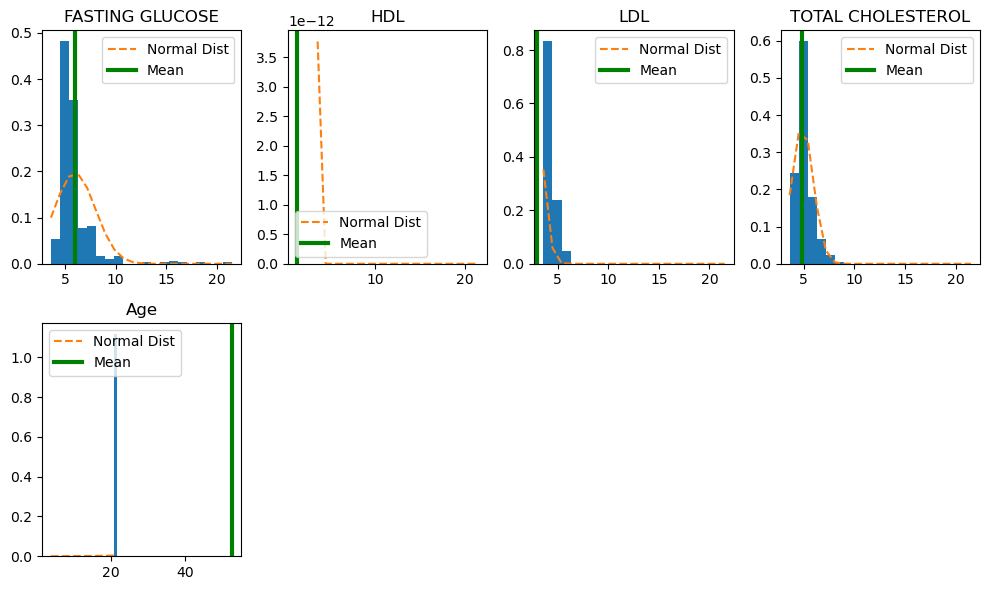

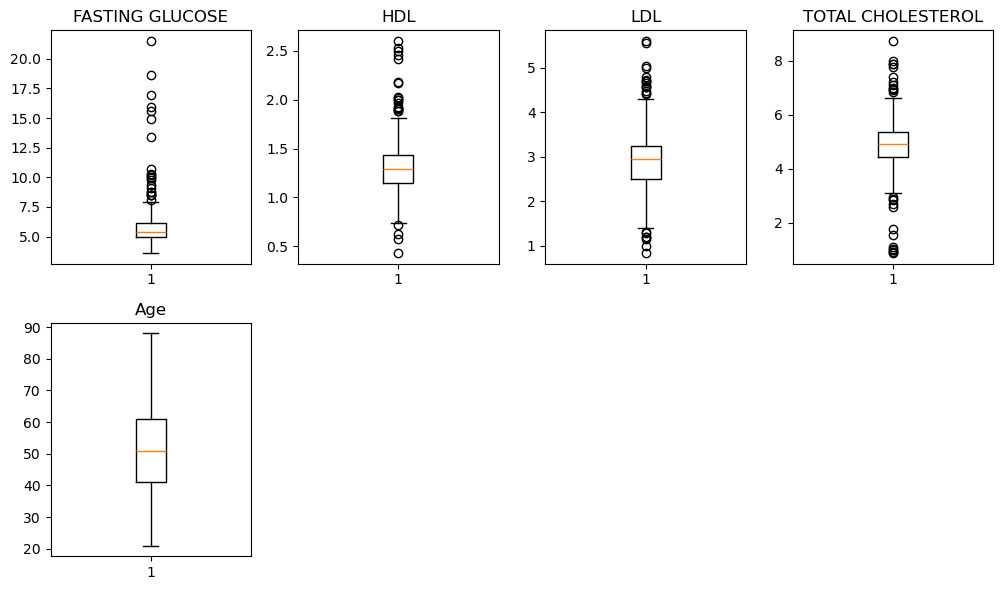

Unique values in State Type Binary: [0 1]


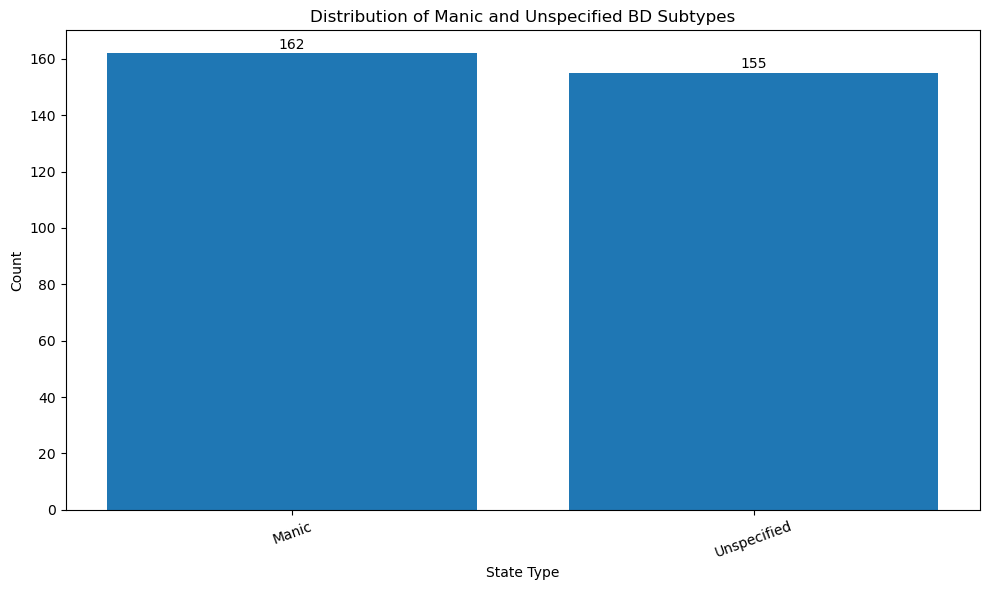

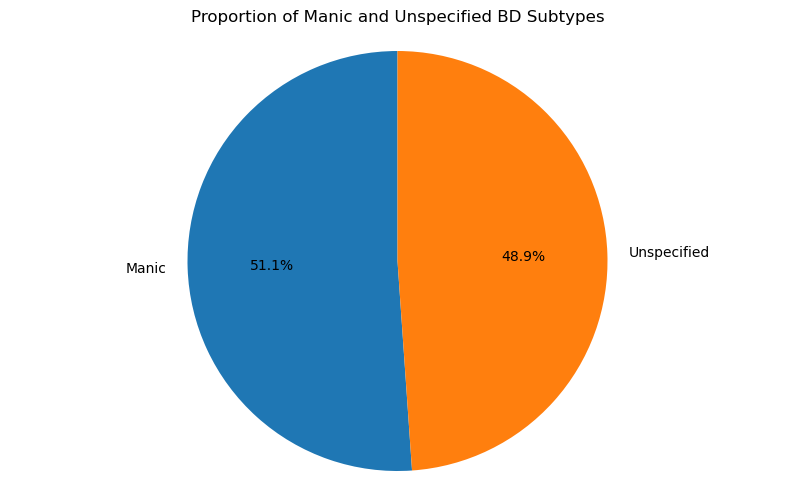

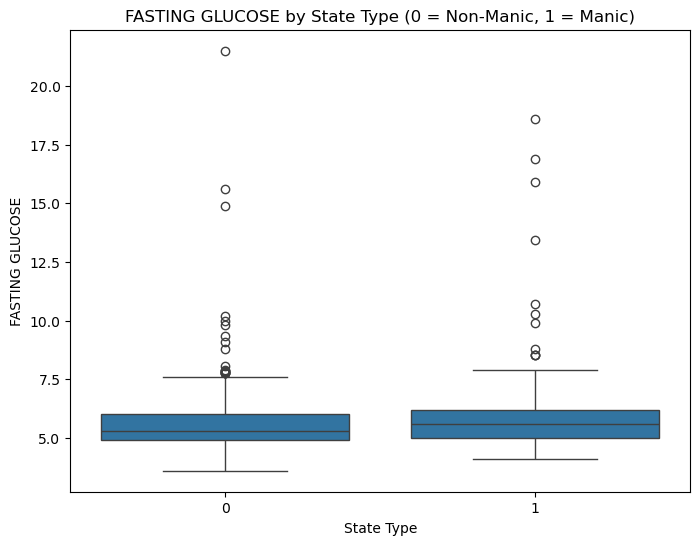

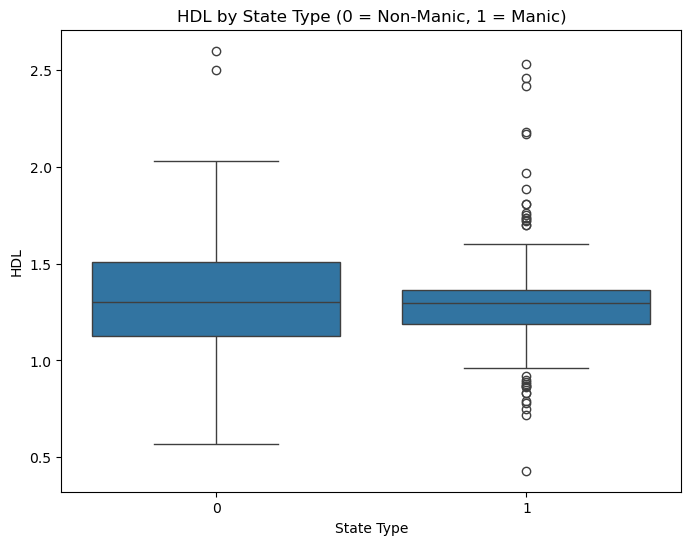

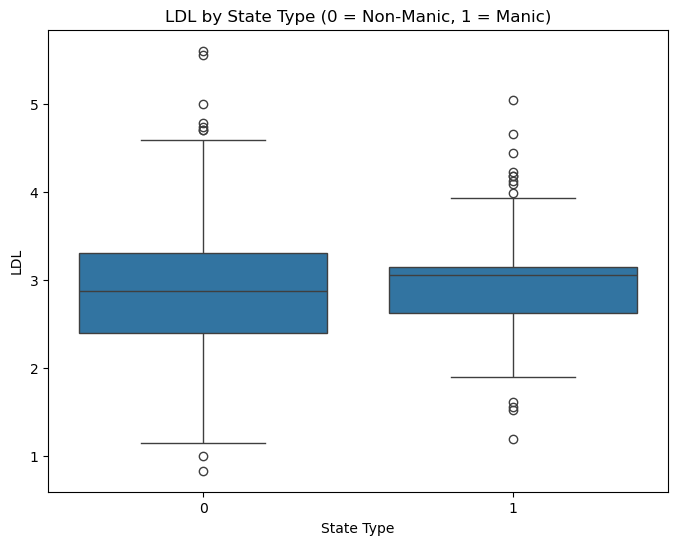

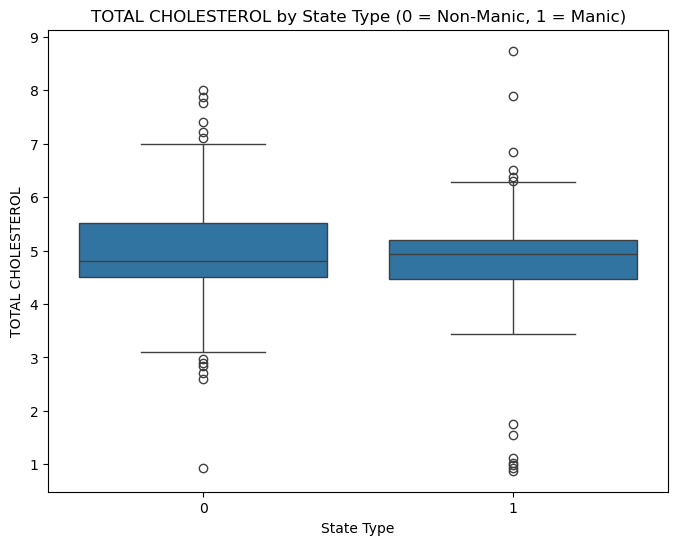

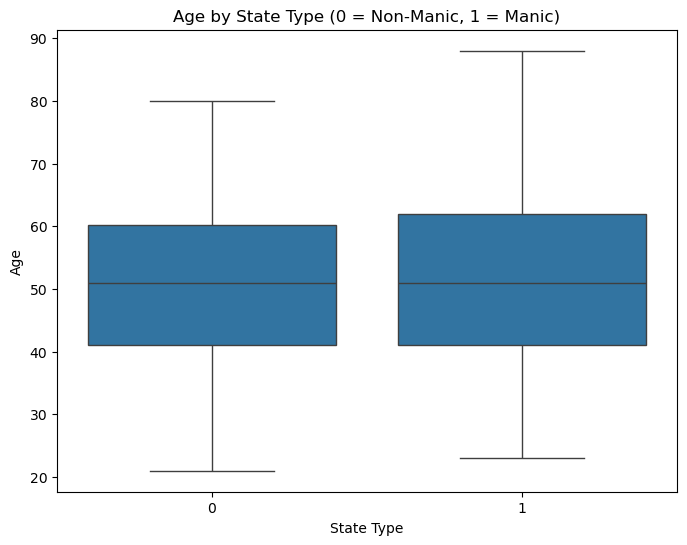

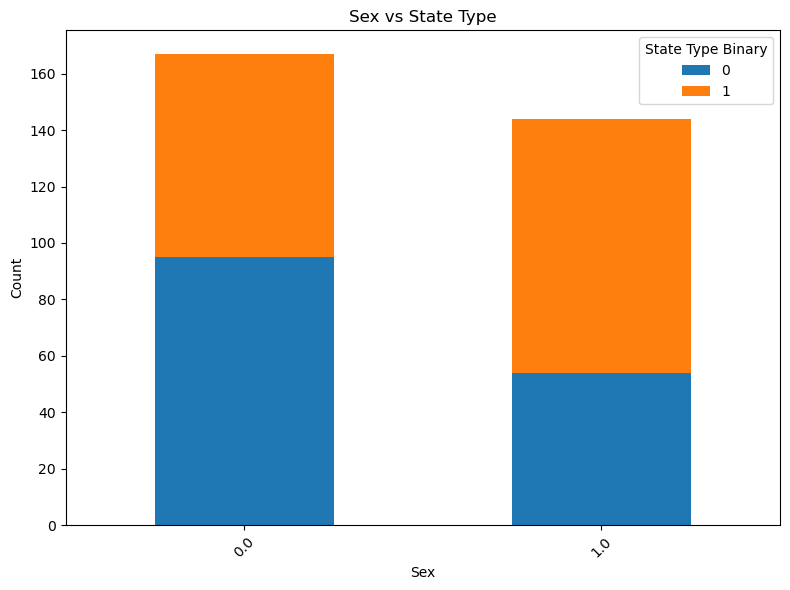

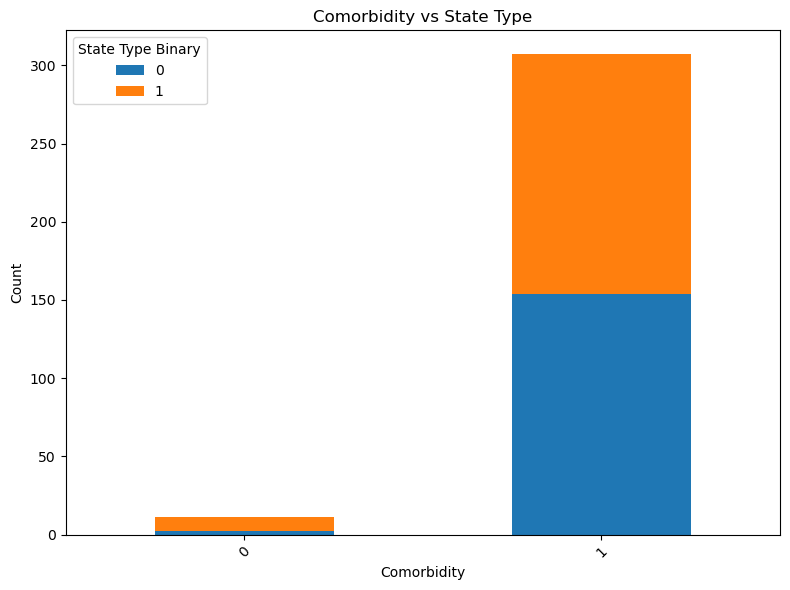

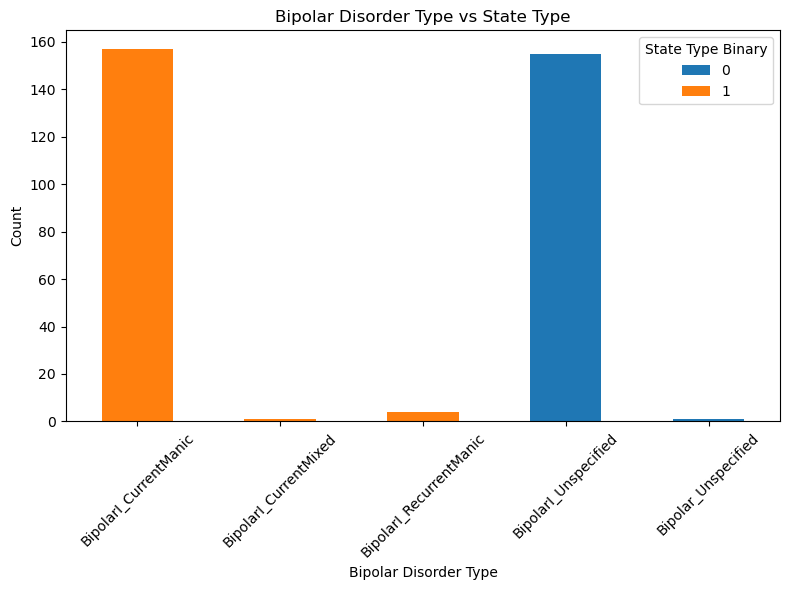

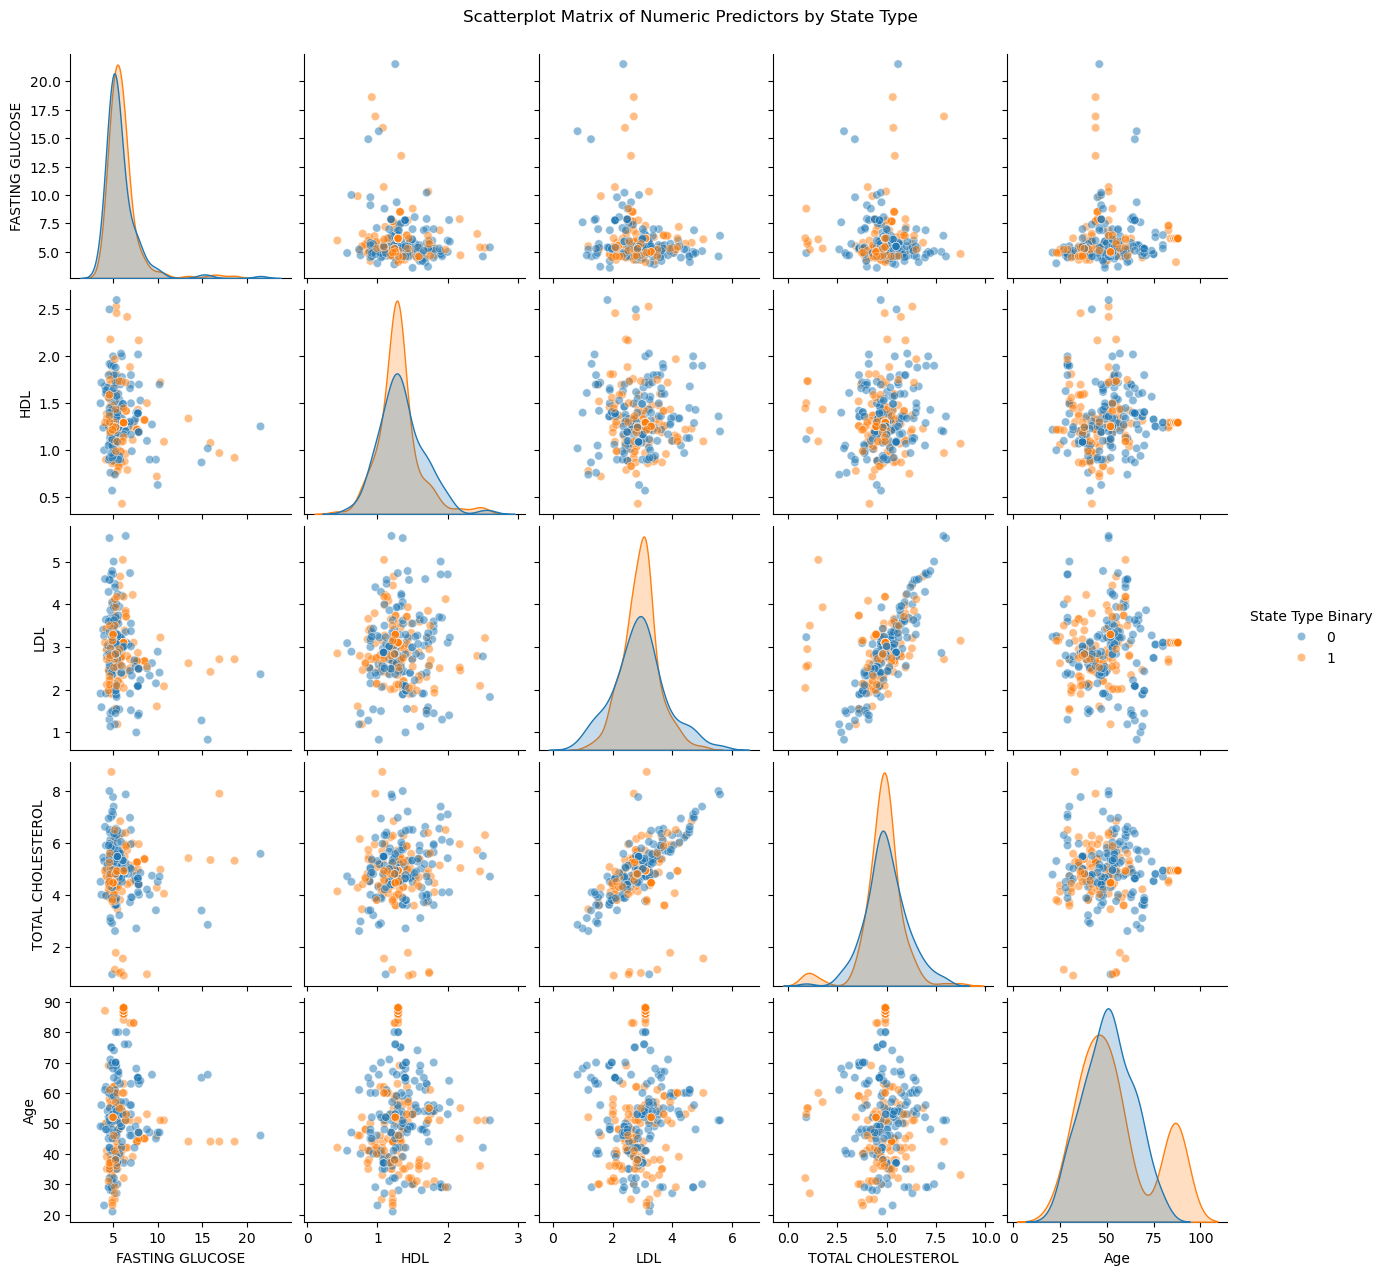


Correlation matrix:
                   FASTING GLUCOSE       HDL       LDL  TOTAL CHOLESTEROL  \
FASTING GLUCOSE           1.000000 -0.124355 -0.206489          -0.013793   
HDL                      -0.124355  1.000000 -0.004263           0.119290   
LDL                      -0.206489 -0.004263  1.000000           0.573067   
TOTAL CHOLESTEROL        -0.013793  0.119290  0.573067           1.000000   
Age                       0.097709  0.018376  0.082145          -0.025724   

                        Age  
FASTING GLUCOSE    0.097709  
HDL                0.018376  
LDL                0.082145  
TOTAL CHOLESTEROL -0.025724  
Age                1.000000  
Error in plot_correlation_matrix: name 'sns' is not defined

Descriptive statistics for FASTING GLUCOSE:
mean: 5.9626
median: 5.4000
mode: 6.1800
std: 2.0270
variance: 4.1088
skewness: 4.0290
kurtosis: 21.5342
percentile_25: 4.9400
percentile_50: 5.4000
percentile_75: 6.1800
IQR: 1.2400

Descriptive statistics for HDL:
mean: 1.3212
me

{'FASTING GLUCOSE': {'mean': np.float64(5.962635220125786),
  'median': np.float64(5.4),
  'mode': np.float64(6.180000000000001),
  'std': np.float64(2.027024581784694),
  'variance': np.float64(4.108828655159415),
  'skewness': np.float64(4.028964225598478),
  'kurtosis': np.float64(21.534221657139483),
  'percentile_25': np.float64(4.94),
  'percentile_50': np.float64(5.4),
  'percentile_75': np.float64(6.180000000000001),
  'IQR': np.float64(1.2400000000000002)},
 'HDL': {'mean': np.float64(1.3211698113207546),
  'median': np.float64(1.294),
  'mode': np.float64(1.294),
  'std': np.float64(0.3127372428421855),
  'variance': np.float64(0.09780458306053211),
  'skewness': np.float64(0.9741178907480034),
  'kurtosis': np.float64(2.508133627609905),
  'percentile_25': np.float64(1.152),
  'percentile_50': np.float64(1.294),
  'percentile_75': np.float64(1.4335),
  'IQR': np.float64(0.2815000000000001)},
 'LDL': {'mean': np.float64(2.9218867924528302),
  'median': np.float64(2.9559999999

<Figure size 800x600 with 0 Axes>

In [8]:
# Load imputed, clean dataset 
df = imp.load_data("bd_labs_imputed_within_2yrs.csv")

# Define column types
meta_cols = ["Patient_ID", "PerformedDate", "BD_Diagnosis_Date", "BD_Code", "BirthYear"]
numeric_cols = ["FASTING GLUCOSE", "HDL", "LDL", "TOTAL CHOLESTEROL", "Age"]
categorical_cols = ["Sex", "Comorbidity"]

# Convert dates and categorical variables
df['PerformedDate'] = pd.to_datetime(df['PerformedDate'], errors='coerce')
df['BD_Diagnosis_Date'] = pd.to_datetime(df['BD_Diagnosis_Date'], errors='coerce')
df['Sex'] = df['Sex'].astype('category')
df['Comorbidity'] = df['Comorbidity'].astype('category')
df['BD_Code'] = df['BD_Code'].astype('category')

# Map and encode subtypes of bipolar disorders
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}
bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)

# Map and encode state types (Manic, Depressed, Unspecified)
state_map = {
    '296.0': 'Manic', '296.1': 'Manic', '296.4': 'Manic',
    '296.5': 'Depressed', '296.6': 'Manic', '296.7': 'Unspecified',
    '296.80': 'Unspecified', '296.89': 'Unspecified'
}
state_order = ['Manic', 'Depressed', 'Unspecified']

df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)

# Add to categorical columns
categorical_cols.extend(['Bipolar Disorder Type', 'State Type'])

# 1. Data Summary
eda.summarize_dataframes(df, name="BD Labs Imputed Within 2 Years")
eda.summarize_numeric_statistics(df, numeric_cols, name="BD Labs Numeric")

# 2. Univariate Analysis
# Numeric variables: Histograms and Boxplots
eda.plot_histograms(df, numeric_cols, bins=20)
eda.plot_boxplots(df, numeric_cols)

# Categorical variables: Bar chart for State Type Binary (Manic vs Non-Manic)
df['State Type Binary'] = (df['State Type'] == 'Manic').astype(int)
eda.plot_bar_chart(df, x_col="State Type Binary", y_col="State Type Binary", title="Distribution of State Type (Manic vs Non-Manic)")
eda.check_unique_values(df, "State Type Binary")

# 3. BD Subtype Distribution (Manic vs Unspecified)
bd_subtype_counts = df[df['State Type'].isin(['Manic', 'Unspecified'])].groupby('State Type').size().reset_index(name='Count')
eda.plot_bar_chart(bd_subtype_counts, x_col="State Type", y_col="Count", title="Distribution of Manic and Unspecified BD Subtypes")
eda.plot_pie_chart(bd_subtype_counts, category_col="State Type", value_col="Count", title="Proportion of Manic and Unspecified BD Subtypes")

# 4. Bivariate Analysis
# Numeric vs State Type Binary (Boxplots)
for num_col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="State Type Binary", y=num_col, data=df)
    plt.title(f"{num_col} by State Type (0 = Non-Manic, 1 = Manic)")
    plt.xlabel("State Type")
    plt.ylabel(num_col.replace('_', ' '))
    plt.show()

# Categorical vs State Type Binary (Bar charts)
for cat_col in ["Sex", "Comorbidity", "Bipolar Disorder Type"]:
    cross_tab = pd.crosstab(df[cat_col], df["State Type Binary"])
    cross_tab.plot(kind='bar', stacked=True, figsize=(8, 6))
    plt.title(f"{cat_col} vs State Type")
    plt.xlabel(cat_col.replace('_', ' '))
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5. Multivariate Analysis
# Scatterplot matrix with hue for State Type Binary
sns.pairplot(df, vars=numeric_cols, hue="State Type Binary", diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Scatterplot Matrix of Numeric Predictors by State Type", y=1.02)
plt.show()

# Correlation matrix for numeric variables
eda.plot_correlation_matrix(df, numeric_cols)

# 6. Detailed Descriptive Statistics
eda.compute_descriptive_stats(df, numeric_cols)
